Stochastic Variational Bayes - example nonlinear model
==============================================

This notebook implements stochastic variational Bayes for a nonlinear model. The model we will use is a bi-exponential model, i.e. we will assume our data reflects a time-dependent signal of the following form:

$$S_{true}(t) = A_1 e^{-R_1t} + A_2 e^{-R_2t}$$

However the actual time dependent signal $S(t)$ will be affected by additive Gaussian noise, so will have the distribution:

$$P(S(t)) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{\bigg(-\frac{\beta}{2} (S(t) - S_{true}(t))^2}\bigg)$$

Given $S(t)$ our aim will be to infer the values of $A_1$, $A_2$, $R_1$, $R_2$ and $\beta$.

Here's how we can generate some sample data from this model in Python:

In [1]:
import numpy as np
from tqdm.notebook import tqdm_notebook
from matplotlib import pyplot as plt
import torch

%matplotlib inline
# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
A1_TRUTH = 10.0
A2_TRUTH = 10.0
R1_TRUTH = 10.0
R2_TRUTH = 1.0
BETA_TRUTH = 1.0
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 200
T = np.linspace(0, 5, N)


DATA_CLEAN = A1_TRUTH * np.exp(-R1_TRUTH * T) + A2_TRUTH * np.exp(-R2_TRUTH*T)
DATA = DATA_CLEAN + np.random.normal(0, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[ 1.78201414e+01  1.86934523e+01  1.52887949e+01  1.55513087e+01
  1.32438526e+01  1.09294164e+01  1.23116814e+01  1.06106543e+01
  8.31087646e+00  9.52316938e+00  6.88265062e+00  8.98001739e+00
  9.11834023e+00  8.47696920e+00  6.35302007e+00  7.42452780e+00
  6.02378004e+00  5.50535760e+00  7.82192399e+00  6.03157304e+00
  6.77541819e+00  6.74368889e+00  5.90896088e+00  4.05781657e+00
  4.39306840e+00  4.02169709e+00  5.11731638e+00  2.88233814e+00
  7.22802778e+00  4.05560550e+00  5.04972971e+00  6.29057041e+00
  5.39625836e+00  4.30057703e+00  5.01676445e+00  4.07650622e+00
  4.33920258e+00  4.05420275e+00  2.26099605e+00  5.58434935e+00
  2.79370838e+00  4.71821427e+00  3.23537029e+00  3.00969626e+00
  3.06113033e+00  3.95228131e+00  4.22373358e+00  4.60130717e+00
  1.08972329e+00  3.39086614e+00  3.51341533e+00  2.88765787e+00
  1.81382925e+00  2.17412326e+00  2.44141411e+00  2.22338771e+00
  3.58780670e+00  2.36377404e+00  1.73141794e+00  3.68399225e+00
  2.109

We can plot this data to illustrate the true signal (green line) and the measured data (red crosses):

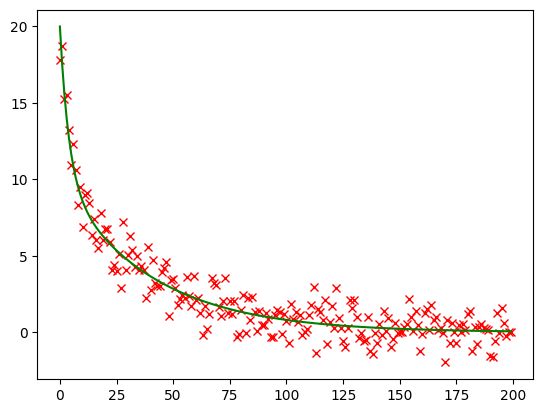

In [2]:
plt.figure()
plt.plot(DATA, "rx")
plt.plot(DATA_CLEAN, "g")
plt.show()

As with the single Gaussian example we will use a multivariate normal distribution as our prior and approximate posterior distributions. 

One difference here is that we will choose to infer the log of the decay rate parameters $R_1$ and $R_2$. This is because if these parameters are allowed to become negative the model prediction will become an exponential growth and can easily lead to numerical errors.

We will still choose our priors to be relatively uninformative as follows:


In [3]:
a0 = 1.0
v0 = 100000.0
r0 = 0.0
u0 = 10.0
b0 = 0.0
w0 = 10.0
print("Priors: Amplitude mean=%f, variance=%f" % (a0, v0))
print("        Log decay rate mean=%f, variance=%f" % (r0, u0))
print("        Log noise variance mean=%f, variance=%f" % (b0, w0))

Priors: Amplitude mean=1.000000, variance=100000.000000
        Log decay rate mean=0.000000, variance=10.000000
        Log noise variance mean=0.000000, variance=10.000000


The posterior will be defined in the same way as for the single Gaussian example, however we need to account for the increased number of parameters we are inferring. We will initialize the posterior with the prior values but with reduced initial variance to prevent problems with generating a representative posterior sample. Remember that the decay rates (and the noise) are being inferred as their log-values so the prior mean of 0 translates into a value of 1.

The code to generate a posterior sample is unchanged except for the number of parameters.

In calculating the reconstruction cost we need to calculate the log likelihood of the data given a set of model parameters. We do this by observing that any difference between the biexponential model prediction (given these parameters) and the actual noisy data must be a result of the Gaussian noise - hence the likelihood is simply the likelihood of drawing these differences from the Gaussian noise distribution:

$$\log P(\textbf{y} | A_1; A_2; r_1; r_2; \beta) = \frac{1}{2} \bigg( N \log \beta - \sum{\frac{(y_n - M_n)^2}{\beta}}\bigg)$$

Here $M_n$ is the model prediction for the nth data point which is calculated by evaluating the biexponential model for the given parameters $A_1$, $A_2$, $r_1$ and $r_2$.

For the latent loss we will again use the analytic expression for the K-L divergence of two MVN distributions with a slight modification to the previous code to account for the different number of parameters (5 vs 2)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Number of parameters - 4 for the biexponential + noise
NUM_PARAMS = 4 + 1

data = torch.tensor(DATA, dtype=dtype, device=device)  # shape [N]
prior_means = torch.tensor([a0, r0, a0, r0, b0], dtype=dtype, device=device)  # shape [NUM_PARAMS]
prior_covariance = torch.diag(torch.tensor([v0, u0, v0, u0, w0], dtype=dtype, device=device))  # [P,P]

post_means_init = prior_means.clone()
post_covariance_init = np.identity(NUM_PARAMS, dtype=np.float32)  # [P,P]

# Trainable variational parameters
chol_off_diag = torch.nn.Parameter(
    torch.zeros_like(torch.tensor(post_covariance_init, dtype=dtype, device=device))
)

chol_log_diag = torch.nn.Parameter(
    torch.log(torch.diag(torch.tensor(post_covariance_init, dtype=dtype, device=device)))
)  # [P]

post_means = torch.nn.Parameter(post_means_init)  # [P]

t = torch.tensor(T, dtype=dtype, device=device).reshape(1, -1)  # [1, N]

def cost_fun():
    # Build Cholesky factor for posterior covariance
    # chol_diag = diag(sqrt(exp(chol_log_diag)))
    chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))  # [P,P]

    # lower triangle (including diag) of chol_off_diag
    tril_off = torch.tril(chol_off_diag)  # [P,P]

    # L = chol_diag + tril_off
    post_covariance_chol = chol_diag + tril_off  # [P,P]

    post_covariance = post_covariance_chol.T @ post_covariance_chol  # [P,P]

    S = 5
    N = 200

    # eps ~ N(0, I) 
    eps = torch.randn((NUM_PARAMS, S), dtype=dtype, device=device)

    samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)

    # post_samples = samples + L @ eps
    post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

    a1 = post_samples[0].reshape(-1, 1)                    # [S,1]
    r1 = torch.exp(post_samples[1].reshape(-1, 1))         # [S,1]
    a2 = post_samples[2].reshape(-1, 1)                    # [S,1]
    r2 = torch.exp(post_samples[3].reshape(-1, 1))         # [S,1]

    log_noise_var = -post_samples[4]                       # [S]
    noise_var = torch.exp(log_noise_var)                   # [S]

    prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

    diff = data.view(1, -1) - prediction                   # [S,N]

    sum_square_diff = torch.sum(diff * diff, dim=1)

    log_likelihood = 0.5 * (
        -log_noise_var * torch.tensor(float(N), device=device, dtype=dtype)
        - (sum_square_diff / noise_var)
    )

    reconstr_loss = -torch.mean(log_likelihood)

    # KL term (latent_loss)
    C = post_covariance
    C0 = prior_covariance
    C0_inv = torch.linalg.inv(C0)

    m_minus_m0 = (post_means - prior_means).reshape(-1, 1)  # [P,1]
    m_minus_m0_T = (post_means - prior_means).reshape(1, -1)  # [1,P]

    term1 = torch.trace(C0_inv @ C)

    
    signC, logdetC = torch.linalg.slogdet(C)
    signC0, logdetC0 = torch.linalg.slogdet(C0)
    term2 = -(logdetC - logdetC0)

    term3 = -NUM_PARAMS
    term4 = (m_minus_m0_T @ C0_inv @ m_minus_m0).squeeze()  # scalar

    latent_loss = 0.5 * (term1 + term2 + term3 + term4)

    cost = reconstr_loss


    return cost

Finally we ask PyTorch to minimise the total cost iteratively:

In [6]:
optimizer = torch.optim.Adam([post_means, chol_log_diag, chol_off_diag], lr=1e-2)

cost_history = []
for epoch in tqdm_notebook(range(5000), desc="Epoch:"):
    optimizer.zero_grad()
    loss = cost_fun()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(epoch, float(loss.detach().cpu()))
    cost_history.append(loss.detach().cpu().numpy())

Epoch::   0%|          | 0/5000 [00:00<?, ?it/s]

0 1987.8648681640625
100 452.6017150878906
200 355.40325927734375
300 298.0682067871094
400 247.97109985351562
500 257.4591064453125
600 236.7209930419922
700 217.72891235351562
800 210.0818328857422
900 207.0149383544922
1000 205.28286743164062
1100 181.3641815185547
1200 177.9564666748047
1300 164.37034606933594
1400 160.48313903808594
1500 150.91357421875
1600 145.2916717529297
1700 134.8665313720703
1800 127.36970520019531
1900 122.7253646850586
2000 116.5826187133789
2100 112.85033416748047
2200 108.97377014160156
2300 105.79328918457031
2400 103.4220199584961
2500 101.6907730102539
2600 100.31193542480469
2700 99.35958862304688
2800 98.86266326904297
2900 98.4874267578125
3000 98.16633605957031
3100 98.02243041992188
3200 97.9676513671875
3300 97.92337799072266
3400 97.85011291503906
3500 97.82164001464844
3600 97.77102661132812
3700 97.79387664794922
3800 97.77544403076172
3900 97.77449798583984
4000 97.76490783691406
4100 97.76022338867188
4200 97.75709533691406
4300 97.7551803

In [7]:
final_means = post_means

# chol_diag = diag(sqrt(exp(chol_log_diag)))
chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))
post_covariance_chol = chol_diag + torch.tril(chol_off_diag)

# post_covariance = L^T L
post_covariance = post_covariance_chol.T @ post_covariance_chol

final_covariance = post_covariance

m = final_means.detach().cpu()
C = final_covariance.detach().cpu()

print("Estimate for amp1: %f (variance: %f)" % (m[0].item(), C[0, 0].item()))
print("Estimate for amp2: %f (variance: %f)" % (m[2].item(), C[2, 2].item()))
print("Estimate for r1: %f" % (torch.exp(m[1]).item(),))
print("Estimate for r2: %f" % (torch.exp(m[3]).item(),))
print("Estimate for beta (noise): %f" % (torch.exp(-m[4]).item(),))

Estimate for amp1: 9.379557 (variance: 0.000009)
Estimate for amp2: 9.770135 (variance: 0.000000)
Estimate for r1: 0.941950
Estimate for r2: 7.678539
Estimate for beta (noise): 0.977631


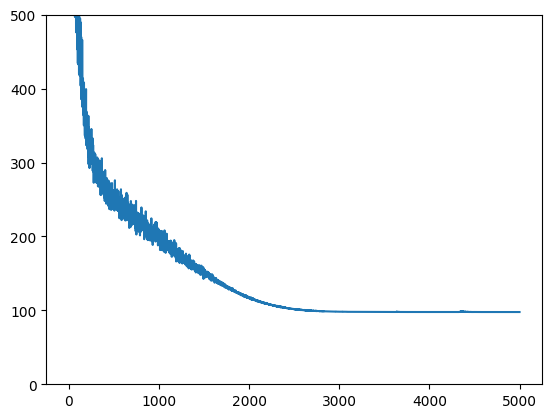

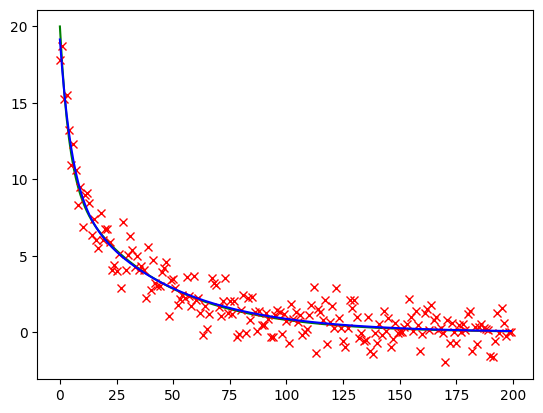

In [8]:
plt.figure()
plt.plot(cost_history)
plt.ylim(0, 500)

plt.figure()
plt.plot(DATA_CLEAN, 'g')
plt.plot(DATA, 'rx')

S = 5

eps = torch.randn((NUM_PARAMS, S), dtype=post_means.dtype, device=post_means.device)

samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)  # [P,S]

post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

a1 = post_samples[0].reshape(-1, 1)            
r1 = torch.exp(post_samples[1].reshape(-1, 1)) 
a2 = post_samples[2].reshape(-1, 1)            
r2 = torch.exp(post_samples[3].reshape(-1, 1)) 

log_noise_var = -post_samples[4]               
noise_var = torch.exp(log_noise_var)

t = torch.tensor(T, dtype=post_means.dtype, device=post_means.device).reshape(1, -1)  # [1,N]
prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

# Plot the first posterior sample prediction
plt.plot(prediction[0].detach().cpu().numpy(), 'b')

plt.show()